# K-Means - Clustering

Os dados normalizados serão preparados selecionando variáveis relevantes (ex.: pH, condutividade elétrica, nitrato). 

O algoritmo será aplicado para agrupar os dados por similaridade, testando n_clusters de 2 a 10, definido pelo método do cotovelo (Kaufman; Russeeuw, 1990). 

O objetivo é identificar padrões espaciais ou temporais (ex.: regiões com alta turbidez) para manejo hídrico. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pcj.utils import BASE_DIR, dados

In [13]:
# Dados para testes

dados_limpos, metadados, variaveis = dados(r"data\processed\dados_limpos.xlsx")

X = dados_limpos.copy()

In [3]:
# Verificações

# print(dados_limpos['Data'].dtype, end='')
# print(dados_limpos['data_normalizada'].dtype)
# print(dados_limpos.columns)
# print(variaveis)
print(dados_limpos[variaveis])

       COR  TURB.   pH  ALC.   AC.  O.C.  O.D.    Cl  DUR.     Fe    Mn  \
0    200.0   64.0  7.0  29.0   3.0   6.3   2.0  16.0  36.0   3.23  0.09   
1    432.0  131.0  7.2  34.0   5.0   6.8   3.5  23.0  47.0   6.26  0.17   
2    690.0  241.0  7.4  38.0   8.0   7.5   4.8  33.0  66.0  11.20  0.32   
3    393.0   72.0  6.5  29.0   6.0   5.9   2.8  20.0  30.0   6.82  0.08   
4    868.0  238.0  7.1  31.0   7.0   7.2   4.1  21.0  33.0   9.55  0.12   
..     ...    ...  ...   ...   ...   ...   ...   ...   ...    ...   ...   
571  217.0  134.0  7.5  48.0   9.0   9.7   4.2  39.0  63.0   1.57  0.11   
572  805.0  746.0  7.8  60.0  18.0  17.6   6.0  45.0  96.0   2.80  0.19   
573    NaN    NaN  NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN   NaN   
574    NaN    NaN  NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN   NaN   
575    NaN    NaN  NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN   NaN   

     Cond.  Cianobacteria     C.F.  Clorofila     F  
0    131.0         6600.0  23000.0       2.23

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### 01 - Minha Tentativa

In [18]:
# Primeira tentativa

from sklearn.cluster import KMeans

# Salvar cópia das colunas das variáveis numa variável
# X = dados_limpos[variaveis].copy() # Acho que talvez não seja necessário *

# Eliminar células vaziass
# X_nonan = X.dropna()    # * Substituindo essa linha pela debaixo
X_nonan = X[variaveis].dropna().copy()

kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(X_nonan)
print(kmeans)

KMeans(n_clusters=2, random_state=0)


In [28]:
# Segunda tentativa, mais elaborada

# Setup

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [29]:
# Salvar cópia das colunas das variáveis numa variável
# X = dados_limpos[variaveis].copy()    # Mesma coisa da primeira tentativa

# Eliminar células vaziass
X_nonan = X[variaveis].dropna(axis=0, how='any')

# Salvar o Index do DataFrame sem células vazias numa variável
idx_nonan = X_nonan.index


In [ ]:
# Normalização dos dados. É um pré requisito para o PCA funcionar
scaler = StandardScaler()   # Coloca todas as variáveis na mesma escala, com média = 0 e desvio padrão = 1.
X_scaled = scaler.fit_transform(X_nonan)

In [31]:
# Redução da dimensionalidade
pca = PCA(n_components=0.95, # Mantém 95% da variância
          random_state=0)
X_pca = pca.fit_transform(X_scaled)

In [32]:
# KMeans - "Bruto" (X_nonan)

kmeans = KMeans(n_clusters=2, # Número de clusters, ajustar para o que for preferido.
                random_state=42)
cluster_labels = kmeans.fit_predict(X_nonan)
distancias = np.linalg.norm(X_nonan - kmeans.cluster_centers_[cluster_labels], axis=1)

kmeans.labels_  # Matriz de 0s e 1s.

distancias  # Distâncias euclidianas entre os pontos. Como não foi normalizado, há uma grande variabilidade entre as distâncias

array([ 10750.54819896,  10659.56335105,  10581.08918187,  19478.03467185,
        19014.33785476,  18591.94726714,  41001.90565024,  40762.83518872,
        40557.6358001 ,   9119.0498794 ,   5483.59658074,   3951.58385794,
        13597.39898501,   9104.90139451,   5484.69786075,   9595.10060185,
        22610.08309448,  67549.61689605,  81346.21994878,  81346.20240749,
        81346.20939416,  12790.49226464,  16131.35272437,  33272.36263063,
         8537.78474532,   8297.78030038,  17588.84626603,  13062.9481368 ,
        40834.22311872, 289965.42346925,  67451.18814027,  66945.57768424,
        67047.80982904,  22539.28962897,  73953.31131367,  70312.68397573,
        19753.98006377,  38043.7307289 ,  57501.95447321,  97474.23836476,
        41040.48542987,  21836.36714042,  80517.31606353,  80517.31434006,
        80519.090407  ,  31752.36639238,  67493.65615747,   9677.27833402,
         8341.93250443,   8341.40136967,   8340.90766375,  13371.80311842,
        22947.81866679,  

In [ ]:
# KMeans - Normalizado

kmeans = KMeans(n_clusters=2, 
                random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)
distancias = np.linalg.norm(X_scaled - kmeans.cluster_centers_[cluster_labels], axis=1)

kmeans.labels_

distancias  # Distâncias euclidianas bem menores, pós normalização

array([ 2.06200933,  2.55380804,  4.74104447,  3.70859079,  4.95652469,
        6.44848783,  3.21850692,  3.28819708,  4.62801494,  1.48747741,
        1.0436654 ,  1.22196402,  1.71200298,  1.00665172,  0.94607095,
        1.3879896 ,  1.11994936,  2.07153368,  2.65253363,  2.44380022,
        2.4636003 ,  1.68546737,  1.61273046,  2.88136899,  3.11674381,
        1.31713222,  3.89787303,  1.73352243,  4.45881445,  9.19441383,
        2.38534309,  2.28060113,  5.00068703,  2.65644695,  6.13752346,
       11.56476024,  2.46509957,  3.17396321,  4.92077041,  2.71129499,
        3.47210161,  5.08666844,  2.92255764,  3.57309582,  5.61594245,
        1.72009012,  2.12036452,  1.59991802,  1.89208375,  1.20742463,
        1.29372445,  2.00807476,  1.14261265,  1.32353613,  1.51690997,
        1.3307291 ,  1.9183364 ,  1.89762547,  1.6628278 ,  2.29976696,
        2.0025636 ,  2.02261597,  2.84824675,  1.61841309,  1.8250883 ,
        2.54004372,  2.02592517,  1.23896514,  2.62615951,  4.52

In [ ]:
# KMeans - PCA

kmeans = KMeans(n_clusters=2,   
                random_state=42)
cluster_labels = kmeans.fit_predict(X_pca)
distancias = np.linalg.norm(X_pca - kmeans.cluster_centers_[cluster_labels], axis=1)

kmeans.labels_

distancias  # Valores similares ao do normalizado, mas com a vantagem de estar em 2 dimensões, permitindo gerar visualizações. 
            # A desvantagem é a perda de 5% de informação, devido ao `n_components = 0.95` de antes.

array([ 2.0395592 ,  2.44837552,  4.53645224,  3.65912115,  4.69075436,
        6.11487247,  3.21523156,  3.27593944,  4.56133489,  1.47158575,
        1.02097082,  1.20205623,  1.67542427,  0.96215068,  0.9042421 ,
        1.32755576,  1.06834426,  2.00215809,  2.64633865,  2.44265474,
        2.4519992 ,  1.67057807,  1.54070344,  2.75748045,  3.11358984,
        1.25604034,  3.80284272,  1.68984826,  4.43134051,  9.0969072 ,
        2.32926023,  2.22793684,  4.95249557,  2.65448001,  6.0249592 ,
       11.31084723,  2.45517494,  3.12862145,  4.7621857 ,  2.62980618,
        3.44039057,  5.06512416,  2.82971683,  3.54200206,  5.54367689,
        1.63108308,  1.99144807,  1.54889119,  1.88749667,  1.17255211,
        1.21578678,  1.9599511 ,  1.08718841,  1.27519331,  1.41455828,
        1.27758818,  1.91346514,  1.86879382,  1.60964328,  2.0980202 ,
        1.93254893,  1.91044058,  2.60241119,  1.56629742,  1.77372957,
        2.45875235,  2.01861609,  1.20470571,  2.5483465 ,  4.46

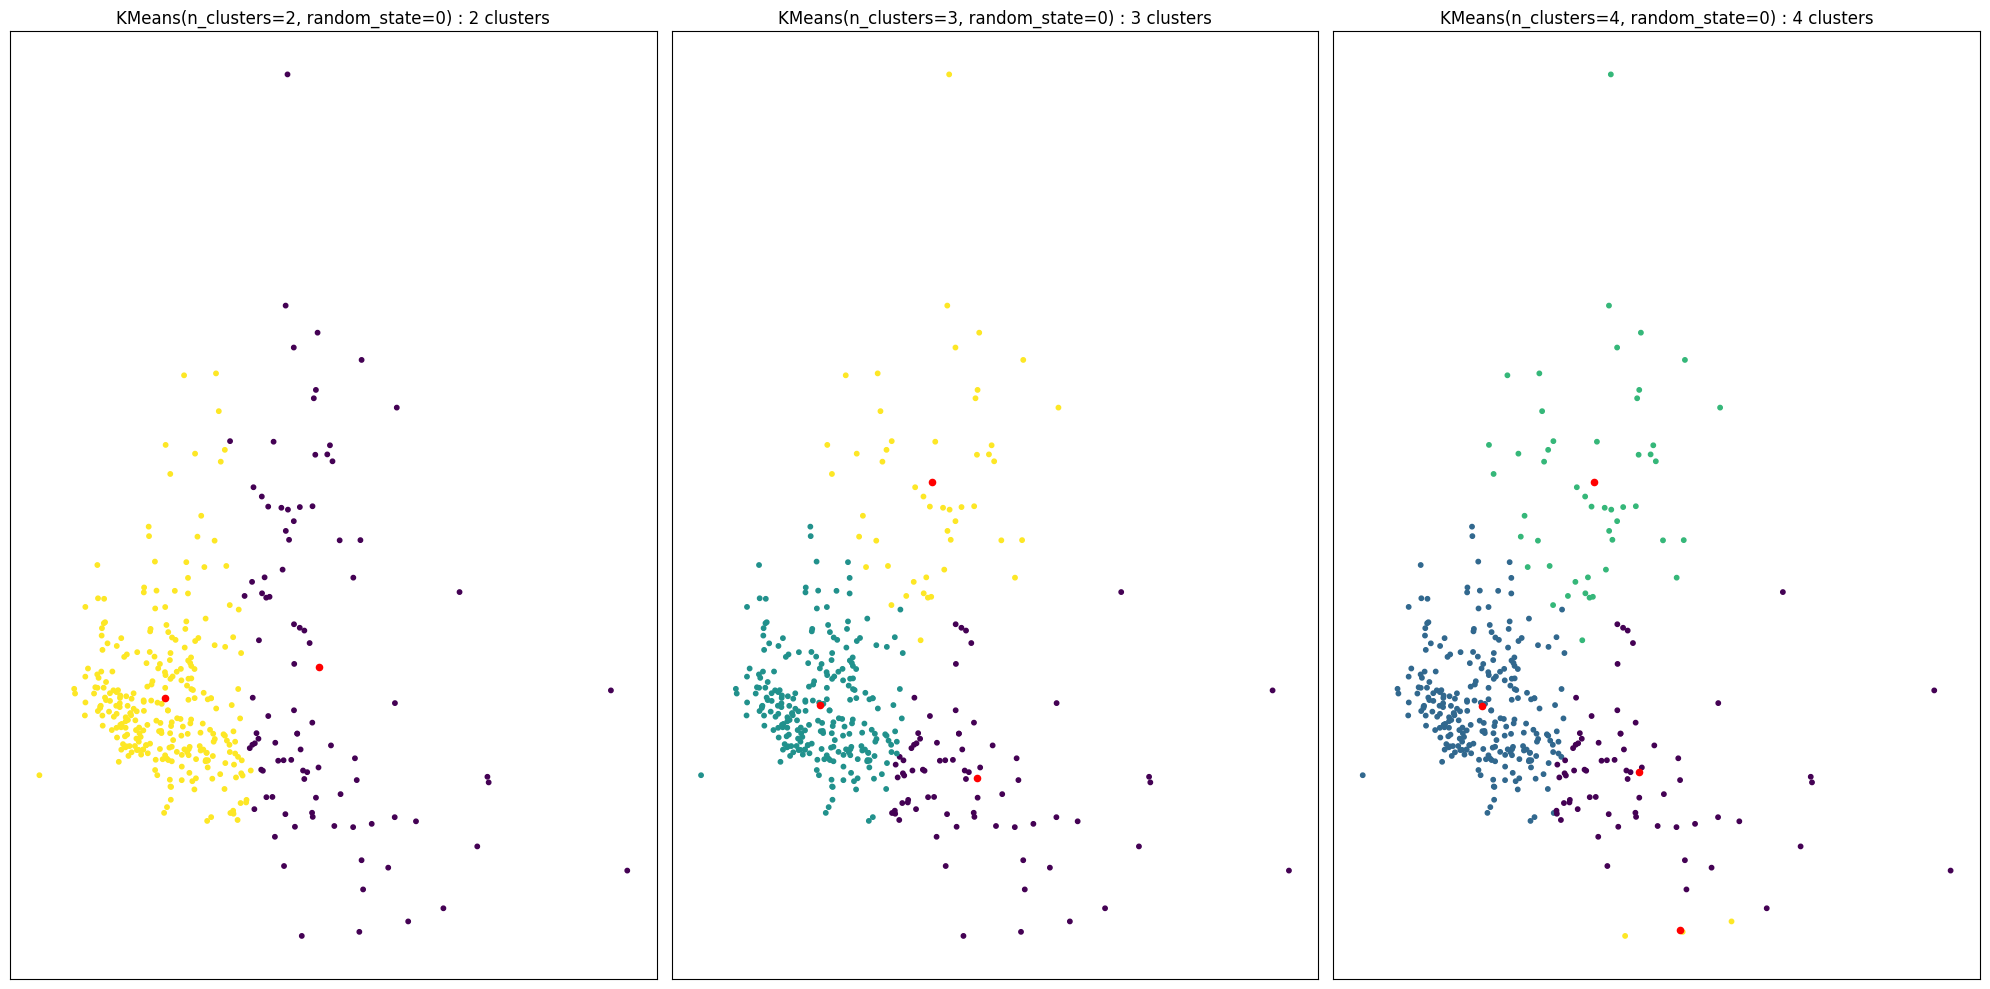

In [35]:
n_clusters_list = [2, 3, 4]

fig, axs = plt.subplots(
    1,
    len(n_clusters_list),
    figsize=(20, 10)
)

axs = axs.T

for i, n_clusters in enumerate(n_clusters_list):
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto")
    kmeans.fit(X_pca)
    centers = kmeans.cluster_centers_

    axs[i].scatter(X_pca[:, 0], X_pca[:, 1], s=10, c=kmeans.labels_)
    axs[i].scatter(centers[:, 0], centers[:, 1], c="r", s=20)

    axs[i].set_title(f"{kmeans} : {n_clusters} clusters")

for ax in axs.flat:
    ax.label_outer()
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

plt.show()

C:\Users\Wary\AppData\Local\Temp\ipykernel_20328\1597893924.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])


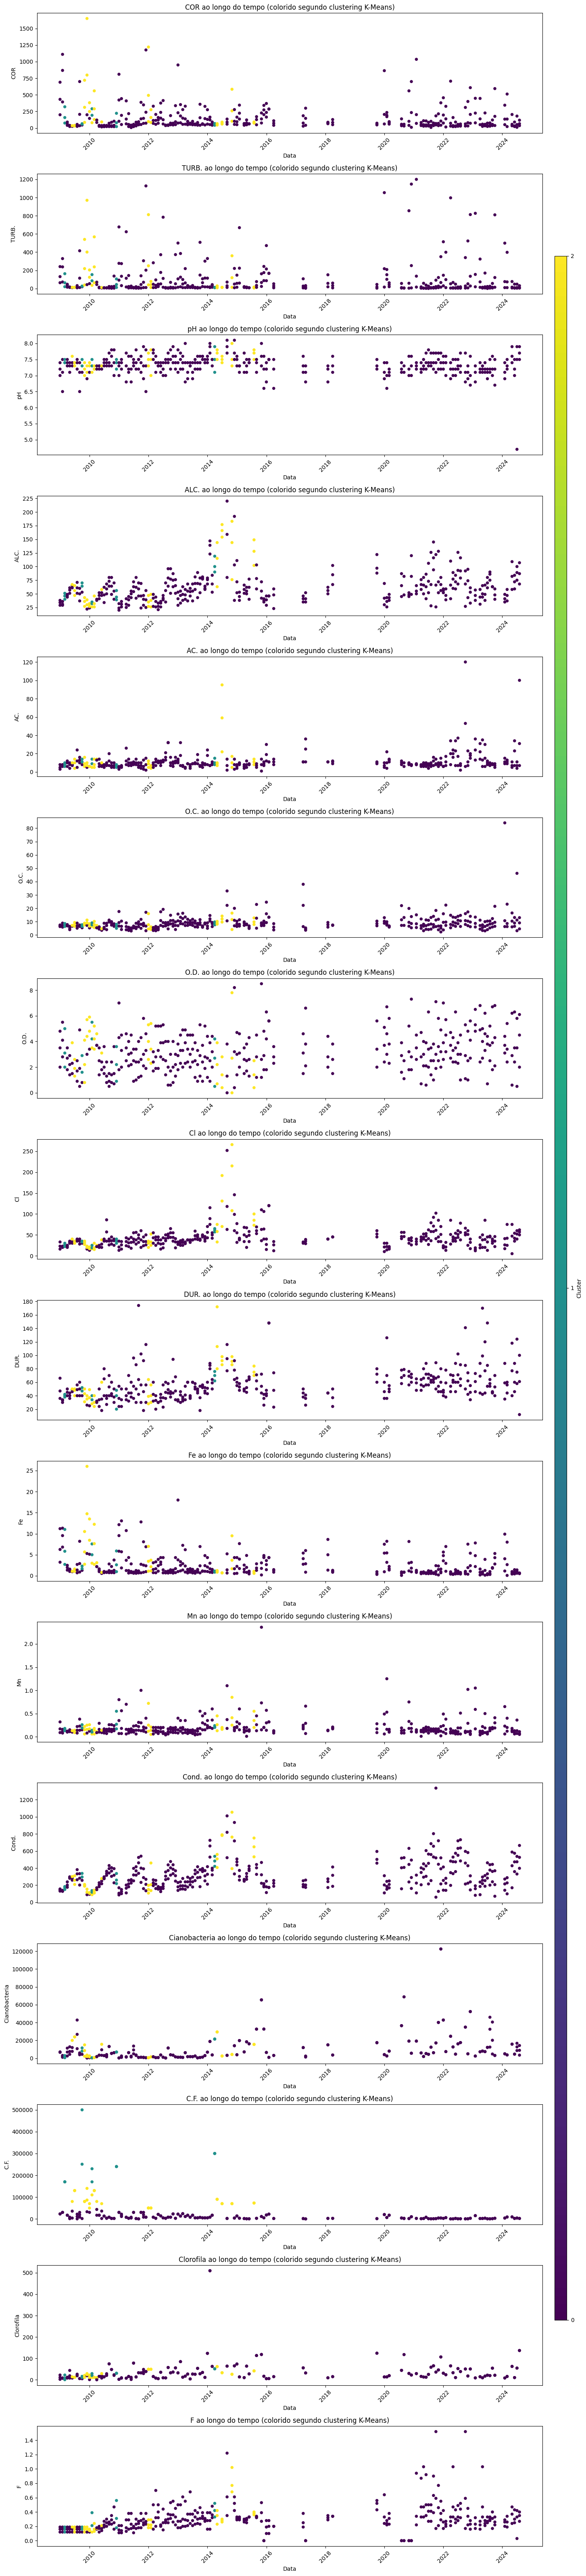

In [25]:
# Teste

n_clusters = 3  # De acordo com os testes anteriores, 3 parece ser o melhor número de clusters

kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto")
kmeans.fit(X_nonan)  # Talvez trocar X_nonan para X_pca
labels = kmeans.labels_

# Extrai datas que correspondem com as linhas de idx_nonan (algumas são removidas devido às células vazias)
dates = dados_limpos.loc[idx_nonan, 'data_normalizada']

# Subplots individuais para as variáveis
fig, axs = plt.subplots(len(variaveis), 1, figsize=(15, 4*len(variaveis)))

if len(variaveis) == 1:
    axs = [axs]

for i, var in enumerate(variaveis):
    scatter = axs[i].scatter(dates, X_nonan[var], c=labels, cmap='viridis', s=20)
    axs[i].set_ylabel(var)
    axs[i].set_xlabel('Data')
    axs[i].set_title(f'{var} ao longo do tempo (colorido segundo clustering K-Means)')
    axs[i].tick_params(axis='x', rotation=45)

cbar_ax = fig.add_axes([0.92, 0.1, 0.02, 0.8])
cbar = fig.colorbar(scatter, cax=cbar_ax, label='Cluster')
cbar.set_ticks(range(n_clusters))

plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.show()